# Extreme search comparison between regular and NN deconvolved tracks

In [1]:
import os
import sys
import glob
import numpy as np
import tables as tb
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
sys.path.append('/home/usc/ie/mpm/NEXT_graphs')

from NEXT_graphNN.utils.read_tensorboard import load_tensorboard_df
from sklearn.metrics import roc_curve, auc

from invisible_cities.io.dst_io import load_dst
sys.path.append(os.getenv('HOME') + '/data_labelling/')

from utils.plotting_utils import plot_3d_hits, plot_3d_vox, plot_cloud_voxels_and_hits, plot_cloud_voxels_and_hits_discrete

sys.path.append(os.getenv('HOME') + '/NEXT_SPARSECONVNET/')

import networkx as nx

In [2]:
test_file = '/mnt/lustre/scratch/nlsas/home/usc/ie/mpm/NEXT100/data/HE_calib/4bar/trains/soph_deco/dataset_4bar_PORT_1a_label_scn_test.h5'
events_info = pd.read_hdf(test_file, 'DATASET/EventsInfo')
events_voxel = pd.read_hdf(test_file, 'DATASET/Voxels')
bins_info = pd.read_hdf(test_file, 'DATASET/BinsInfo')

In [62]:
test_file_pred = '/mnt/lustre/scratch/nlsas/home/usc/ie/mpm/NEXT100/data/HE_calib/4bar/trains/soph_deco/train_D/pred_file.h5'
voxels_pred = pd.read_hdf(test_file_pred, 'DATASET/VoxelsPred')

# This is the thresholded file, contains the info of the thresholds for each event
test_file_thr = '/mnt/lustre/scratch/nlsas/home/usc/ie/mpm/NEXT100/data/HE_calib/4bar/trains/soph_deco/train_D/pred_file_thr.h5'
events_info_pred = pd.read_hdf(test_file_thr, 'DATASET/EventsInfo')


In [63]:
# Add the threshold to the predicted voxels as a column

voxels_pred = voxels_pred.merge(events_info_pred[['dataset_id', 'threshold', 'event_id']])

Let's do the whole process

In [5]:
labelpathname = events_info_pred.label_pathname.unique()[0]
labelbasename = events_info_pred.label_basename.unique()[0]
labelfile = labelpathname + '/' +labelbasename

In [49]:
sophpathname = events_info_pred.pathname.unique()[0]
sophbasename = events_info_pred.basename.unique()[0]
sophfile = sophpathname + '/' +sophbasename

In [50]:
reco = pd.read_hdf(sophfile, 'RECO/Events')

BETTER IDEA: TAKE SOPHRONIA AND RUN ISAURA; FOR THE THRESHOLDED, TAKE SOPHRONIA, VOXELIZE LIKE FOR THE LABELLING, MASK THE SURVIVING HITS USING THE VOXEL SCORES, REDISTRIBUTE THEIR ENERGY PER SLICE (I THINK I HAVE FUNCTIONS FROM SOPHRONIA THAT DO THAT), AND THEN FINALLY SAVE THE FILE AS A NEW SOPRHONIA HIT FILE THAT CAN BE PASSED THROUGH ISAURA

In [53]:
from utils.bin_utils          import bins_creator_sipm, create_bins
from invisible_cities.database          import load_db as db


# Create bins
min_, max_, size_ = (-500, -500, 0), (500, 500, 1300), (10, 10, 10)

sipm_db = db.DataSiPM('next100', 0)
bin_info = bins_creator_sipm(sipm_db, min_[-1], max_[-1], size_[-1])
bins, bin_info = create_bins(bin_info)

In [56]:
bname = ['xbin', 'ybin', 'zbin']
coords = ['X', 'Y', 'Z']
# Voxelize
for i in range(3): reco[bname[i]] = pd.cut(reco[coords[i]], bins[i], labels = np.arange(0, len(bins[i])-1)).astype('int') 
       

In [85]:
# Clean the NaN values in reco because apparently in the labelling those hits do not appear, i don't remember but probably i just 
# delete them in the labelling

reco = reco[~reco.Ec.isna()]

In [90]:
reco = reco.merge(voxels_pred[['event_id', 'xbin', 'ybin', 'zbin', 'class_1', 'threshold']].rename(columns={'event_id':'event'}), on = ['event', 'xbin', 'ybin', 'zbin'], how = 'left')

With this dataframe I can thresholdear already and apply the energy redistribution. Look in the HE analysis and lets see what happens

In [92]:
reco[reco.class_1 > reco.threshold]

,event,time,npeak,Xpeak,Ypeak,nsipm,X,Y,Xrms,Yrms,...,E,Qc,Ec,track_id,Ep,xbin,ybin,zbin,class_1,threshold
2,81000000,1.620000e+14,1,196.651351,171.470492,1,227.675,106.975,0.0,0.0,...,933.661877,-1.0,0.002338,-1,-1.0,46,38,49,0.742214,0.311973
3,81000000,1.620000e+14,1,196.651351,171.470492,1,149.925,338.225,0.0,0.0,...,1015.742112,-1.0,0.002665,-1,-1.0,41,53,49,0.588162,0.311973
5,81000000,1.620000e+14,1,196.651351,171.470492,1,227.675,122.525,0.0,0.0,...,1141.919585,-1.0,0.002871,-1,-1.0,46,39,49,0.343812,0.311973
6,81000000,1.620000e+14,1,196.651351,171.470492,1,149.925,322.675,0.0,0.0,...,1033.165367,-1.0,0.002684,-1,-1.0,41,52,49,0.661353,0.311973
7,81000000,1.620000e+14,1,196.651351,171.470492,1,149.925,338.225,0.0,0.0,...,1132.856734,-1.0,0.002972,-1,-1.0,41,53,49,0.588162,0.311973
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101870,81000104,1.620002e+14,0,269.861011,183.548203,1,288.875,198.775,0.0,0.0,...,1295.770212,-1.0,0.003368,-1,-1.0,50,44,48,0.690613,0.474924
101879,81000104,1.620002e+14,0,269.861011,183.548203,1,288.875,198.775,0.0,0.0,...,1109.157438,-1.0,0.002883,-1,-1.0,50,44,49,0.713783,0.474924
101894,81000104,1.620002e+14,0,269.861011,183.548203,1,288.875,198.775,0.0,0.0,...,481.191042,-1.0,0.001251,-1,-1.0,50,44,49,0.713783,0.474924
101904,81000104,1.620002e+14,0,269.861011,183.548203,1,288.875,198.775,0.0,0.0,...,711.416341,-1.0,0.001850,-1,-1.0,50,44,49,0.713783,0.474924


In [93]:
reco

,event,time,npeak,Xpeak,Ypeak,nsipm,X,Y,Xrms,Yrms,...,E,Qc,Ec,track_id,Ep,xbin,ybin,zbin,class_1,threshold
0,81000000,1.620000e+14,1,196.651351,171.470492,1,149.925,353.775,0.0,0.0,...,1137.198562,-1.0,0.003052,-1,-1.0,41,54,48,0.104947,0.311973
1,81000000,1.620000e+14,1,196.651351,171.470492,1,165.475,322.675,0.0,0.0,...,1333.267224,-1.0,0.003483,-1,-1.0,42,52,48,0.285246,0.311973
2,81000000,1.620000e+14,1,196.651351,171.470492,1,227.675,106.975,0.0,0.0,...,933.661877,-1.0,0.002338,-1,-1.0,46,38,49,0.742214,0.311973
3,81000000,1.620000e+14,1,196.651351,171.470492,1,149.925,338.225,0.0,0.0,...,1015.742112,-1.0,0.002665,-1,-1.0,41,53,49,0.588162,0.311973
4,81000000,1.620000e+14,1,196.651351,171.470492,1,165.475,353.775,0.0,0.0,...,1087.562243,-1.0,0.003035,-1,-1.0,42,54,49,0.158294,0.311973
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101909,81000104,1.620002e+14,0,269.861011,183.548203,1,273.325,198.775,0.0,0.0,...,583.093654,-1.0,0.001509,-1,-1.0,49,44,49,0.361898,0.474924
101910,81000104,1.620002e+14,0,269.861011,183.548203,1,288.875,198.775,0.0,0.0,...,847.690841,-1.0,0.002204,-1,-1.0,50,44,49,0.713783,0.474924
101911,81000104,1.620002e+14,0,269.861011,183.548203,1,304.425,198.775,0.0,0.0,...,578.193749,-1.0,0.001518,-1,-1.0,51,44,49,0.274548,0.474924
101912,81000104,1.620002e+14,0,269.861011,183.548203,1,304.425,214.325,0.0,0.0,...,499.794578,-1.0,0.001318,-1,-1.0,51,45,49,0.159565,0.474924


In [64]:
voxels_pred

,label,energy,dataset_id,xbin,ybin,zbin,class_0,class_1,threshold,event_id
0,0,0.000402,0,37,51,52,0.990994,0.009006,0.311973,81000000
1,0,0.000832,0,38,43,52,0.982120,0.017880,0.311973,81000000
2,0,0.000463,0,38,44,52,0.986068,0.013932,0.311973,81000000
3,0,0.000436,0,38,47,52,0.990501,0.009499,0.311973,81000000
4,0,0.000938,0,38,47,53,0.988597,0.011403,0.311973,81000000
...,...,...,...,...,...,...,...,...,...,...
5280416,0,0.000395,15037,30,30,60,0.918964,0.081036,0.082934,89940112
5280417,0,0.000821,15037,30,31,60,0.954059,0.045941,0.082934,89940112
5280418,0,0.000355,15037,30,33,61,0.980561,0.019439,0.082934,89940112
5280419,0,0.000409,15037,30,34,61,0.977672,0.022328,0.082934,89940112


,event_id,dataset_id
0,81000000,0
1,81000001,1
2,81000002,2
3,81000003,3
4,81000004,4
...,...,...
15033,89940108,15033
15034,89940109,15034
15035,89940110,15035
15036,89940111,15036


In [57]:
reco

,event,time,npeak,Xpeak,Ypeak,nsipm,X,Y,Xrms,Yrms,Z,Q,E,Qc,Ec,track_id,Ep,xbin,ybin,zbin
0,81000000,1.620000e+14,1,196.651351,171.470492,1,149.925,353.775,0.0,0.0,489.015201,5.043478,1137.198562,-1.0,0.003052,-1,-1.0,41,54,48
1,81000000,1.620000e+14,1,196.651351,171.470492,1,165.475,322.675,0.0,0.0,489.015201,5.913043,1333.267224,-1.0,0.003483,-1,-1.0,42,52,48
2,81000000,1.620000e+14,1,196.651351,171.470492,1,227.675,106.975,0.0,0.0,490.773036,5.275362,933.661877,-1.0,0.002338,-1,-1.0,46,38,49
3,81000000,1.620000e+14,1,196.651351,171.470492,1,149.925,338.225,0.0,0.0,490.773036,5.739130,1015.742112,-1.0,0.002665,-1,-1.0,41,53,49
4,81000000,1.620000e+14,1,196.651351,171.470492,1,165.475,353.775,0.0,0.0,490.773036,6.144928,1087.562243,-1.0,0.003035,-1,-1.0,42,54,49
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102062,81000104,1.620002e+14,0,269.861011,183.548203,1,273.325,198.775,0.0,0.0,495.829802,6.898551,583.093654,-1.0,0.001509,-1,-1.0,49,44,49
102063,81000104,1.620002e+14,0,269.861011,183.548203,1,288.875,198.775,0.0,0.0,495.829802,10.028986,847.690841,-1.0,0.002204,-1,-1.0,50,44,49
102064,81000104,1.620002e+14,0,269.861011,183.548203,1,304.425,198.775,0.0,0.0,495.829802,6.840580,578.193749,-1.0,0.001518,-1,-1.0,51,44,49
102065,81000104,1.620002e+14,0,269.861011,183.548203,1,304.425,214.325,0.0,0.0,495.829802,5.913043,499.794578,-1.0,0.001318,-1,-1.0,51,45,49


In [6]:
label_reco = pd.read_hdf(labelfile, 'DATASET/RecoVoxels')

In [7]:
# Taking the prediction basic info per event 
labelinfopred = events_info_pred[events_info_pred.label_basename == labelbasename][['dataset_id', 'binclass', 'total_energy', 'threshold', 'event_id']]

In [8]:
# Joining to the reconstructed labelled voxels the probability info for each voxel
# Remember, for other files we have to correct the dataset id because the info from labelinfopred has the ID from the whole
# testing file, while the label_reco has the ID of each individual label file, which is from 0 to N
# For now we using the first file so no problem
label_reco = label_reco.merge(voxels_pred[(np.isin(voxels_pred.dataset_id, labelinfopred.dataset_id.unique()))][['dataset_id', 'xbin', 'ybin', 'zbin', 'class_1', 'threshold']])

In [14]:
event = label_reco[label_reco.dataset_id == 0]

In [40]:
make_track_graphs(event, np.sqrt(3))[0]

In [45]:
from itertools import combinations

def connected_component_subgraphs(G):
    return (G.subgraph(c).copy() for c in nx.connected_components(G))

# def make_track_graphs(voxels, contiguity):
#     """Create a graph where the voxels are the nodes and the edges are any
#     pair of neighbour voxel. Two voxels are considered to be
#     neighbours if their distance normalized to their size is smaller
#     than a contiguity factor.
#     """

#     voxel_graph = nx.Graph()
#     nodes = [(tuple(v[:3]), {'energy':v[-1]}) for v in voxels]
#     voxel_graph.add_nodes_from(nodes)
#     for va, vb in combinations([n for n, _ in nodes], 2):
#         dist = np.linalg.norm(np.array(va) - np.array(vb)) 
#         if dist <= contiguity: # because we use sqrt(3)
#             voxel_graph.add_edge(va, vb, distance = dist)
#     return tuple(connected_component_subgraphs(voxel_graph))

# faster way to create a graph

from scipy.spatial import KDTree

def make_track_graphs(event, contiguity, columns = ['xbin', 'ybin', 'zbin', 'energy', 'nhits']):
    '''
    Creates a graph using a KDTree for efficient distance computations.
    '''
    voxels = event[columns].values
    nodes = [(tuple(v[:3]), {'energy':v[-2], 'nhits':v[-1]}) for v in voxels]
    pos_nodes = [n for n, _ in nodes]

    graph = nx.Graph()
    graph.add_nodes_from(nodes)
    
    # Use KDTree for fast neighbor search
    kdtree = KDTree(pos_nodes)
    pairs = kdtree.query_pairs(r=contiguity + sys.float_info.epsilon) # add epsilon to include the contiguity value itself
    
    # Add edges for nodes within contiguity
    for i, j in pairs:
        graph.add_edge(pos_nodes[i], pos_nodes[j])
    return tuple(connected_component_subgraphs(graph))

get_track_energy = lambda x: sum([x.nodes[n]['energy'] for n in x])


def shortest_paths(track_graph):
    """Compute shortest path lengths between all nodes in a weighted graph."""
    voxel_pos = lambda x: x[0]

    distances = dict(nx.all_pairs_dijkstra_path_length(track_graph, weight='distance'))

    # sort the output so the result is reproducible
    distances = { v1 : {v2:d for v2, d in sorted(dmap.items(), key=voxel_pos)}
                  for v1, dmap in sorted(distances.items(), key=voxel_pos)}
    return distances


def find_extrema_and_length(distance):
    """Find the extrema and the length of a track, given its dictionary of distances."""
    if not distance:
        print('No voxels')
    if len(distance) == 1:
        only_voxel = next(iter(distance))
        return (only_voxel, only_voxel, 0.)
    first, last, max_distance = None, None, 0
    for (voxel1, dist_from_voxel_1_to), (voxel2, _) in combinations(distance.items(), 2):
        d = dist_from_voxel_1_to[voxel2]
        if d > max_distance:
            first, last, max_distance = voxel1, voxel2, d
    return first, last, max_distance

def find_extrema(track):
    """Find the pair of voxels separated by the greatest geometric
      distance along the track.
    """
    distances = shortest_paths(track)
    extremum_a, extremum_b, _ = find_extrema_and_length(distances)
    return extremum_a, extremum_b

In [46]:
import copy
import numpy as np
import networkx as nx
import sys

VOXEL_SPACING = np.array([15.55, 15.55, 10.0])

def remove_exterior_voxels(
    df,
    energy_threshold,
    min_vxls       = 3,
    contiguity     = np.sqrt(3),
    columns        = ['xbin', 'ybin', 'zbin', 'energy', 'nhits']
):

    def get_neighbours(idx, mod_df, coord_to_index):
        """Return indices of all neighbours of voxel at idx using grid lookup."""
        x = mod_df.at[idx, 'xbin']
        y = mod_df.at[idx, 'ybin']
        z = mod_df.at[idx, 'zbin']

        neighbours = []

        for dx in (-1,0,1):
            for dy in (-1,0,1):
                for dz in (-1,0,1):

                    if dx == 0 and dy == 0 and dz == 0:
                        continue

                    key = (x+dx, y+dy, z+dz)

                    if key in coord_to_index:
                        neighbours.append(coord_to_index[key])

        return neighbours


    def drop_voxel(mod_df, idx, coord_to_index):
        """Drop voxel and redistribute its energy."""

        neighbour_idx = get_neighbours(idx, mod_df, coord_to_index)

        if not neighbour_idx:
            coord = (
                mod_df.at[idx,'xbin'],
                mod_df.at[idx,'ybin'],
                mod_df.at[idx,'zbin']
            )
            del coord_to_index[coord]
            return mod_df.drop(index=idx)

        dropped_energy = mod_df.at[idx, 'energy']

        neighbour_energies = mod_df.loc[neighbour_idx, 'energy']
        total_neighbour_energy = neighbour_energies.sum()

        if total_neighbour_energy > 0:

            for nidx in neighbour_idx:
                weight = mod_df.at[nidx, 'energy'] / total_neighbour_energy
                mod_df.at[nidx, 'energy'] += dropped_energy * weight

        else:

            share = dropped_energy / len(neighbour_idx)

            for nidx in neighbour_idx:
                mod_df.at[nidx, 'energy'] += share

        coord = (
            mod_df.at[idx,'xbin'],
            mod_df.at[idx,'ybin'],
            mod_df.at[idx,'zbin']
        )

        del coord_to_index[coord]

        return mod_df.drop(index=idx)


    mod_df = df.copy()
    dropped_rows = []

    # Build coordinate lookup dictionary
    coord_to_index = {
        (row.xbin, row.ybin, row.zbin): idx
        for idx, row in mod_df.iterrows()
    }

    modified = True

    while modified:

        modified = False

        tracks = make_track_graphs(mod_df, contiguity=contiguity, columns=columns)

        for track in tracks:

            if len(track.nodes()) < min_vxls:
                continue

            extremum_a, extremum_b = find_extrema(track)

            for extreme_pos in (extremum_a, extremum_b):

                idx = coord_to_index.get(tuple(extreme_pos))

                if idx is None:
                    continue

                if mod_df.at[idx, 'energy'] >= energy_threshold:
                    continue

                neighbour_idx = get_neighbours(idx, mod_df, coord_to_index)

                if len(neighbour_idx) < 1:
                    continue

                dropped_rows.append(mod_df.loc[idx].copy())

                mod_df = drop_voxel(mod_df, idx, coord_to_index)

                modified = True
                break

            if modified:
                break


    dropped_df = (
        pd.DataFrame(dropped_rows)
        if dropped_rows
        else pd.DataFrame(columns=mod_df.columns)
    )

    return mod_df.reset_index(drop=True), dropped_df.reset_index(drop=True)


In [47]:
mod, drop = remove_exterior_voxels(
    event,
    0.01,
    min_vxls       = 3,
    contiguity     = np.sqrt(3),  # corner contiguity in bin units (diagonal = sqrt(3))
    columns        = ['xbin', 'ybin', 'zbin', 'energy', 'nhits']
)

In [44]:
len(mod), len(drop)

(350, 33)

In [24]:
len(mod), len(drop)

(345, 38)

In [57]:
def endpoint_distance(t1, t2, c1, c2, spacing = (1, 1, 1)):

    def d(a, b):
        return np.linalg.norm((np.array(a) - np.array(b)) * spacing)

    pairings = [
        (d(t1,c1) + d(t2,c2), (d(t1,c1), d(t2,c2))),
        (d(t1,c2) + d(t2,c1), (d(t1,c2), d(t2,c1))),
    ]

    return min(pairings, key=lambda x: x[0])[1]


In [60]:
def get_event_extremes(event, threshold, true_ext, contiguity = np.sqrt(3), spacing = (1, 1, 1)):

    event_th = event[event.class_1 > threshold]

    tracks = make_track_graphs(event, contiguity)
    tracks = sorted(tracks, key = get_track_energy, reverse=True)

    tracks_th = make_track_graphs(event_th, contiguity)
    tracks_th = sorted(tracks_th, key = get_track_energy, reverse=True)

    # Do this only for the most energetic track
    t = tracks[0]
    extr1, extr2, length = find_extrema_and_length(shortest_paths(t))
    dist_true = endpoint_distance(true_ext[0], true_ext[1], extr1, extr2, spacing = spacing)

    t_th = tracks_th[0]
    extr1_th, extr2_th, length_th = find_extrema_and_length(shortest_paths(t_th))
    dist_true_th = endpoint_distance(true_ext[0], true_ext[1], extr1_th, extr2_th, spacing = spacing)

    return (extr1, extr2, length, dist_true), (extr1_th, extr2_th, length_th, dist_true_th)

In [7]:
# extremes_position = []
# for dat_id in events_voxel.dataset_id.unique():
#     print(dat_id)
#     true_ext = events_voxel[(events_voxel.dataset_id == dat_id) & (events_voxel.extlabel != 0)][['xbin', 'ybin', 'zbin']].values
#     if len(true_ext) != 2:
#         continue
#     event = voxels_pred[voxels_pred.dataset_id == dat_id]
#     thr = events_info_pred[events_info_pred.dataset_id == dat_id].threshold.values[0]
#     event_thr = event[(event.dataset_id == dat_id) & (event.class_1 > thr)]

#     extremes_position.append([dat_id, get_event_extremes(event, thr, true_ext, spacing = (1, 1, 1))])
    

In [7]:
import pickle

# with open("/mnt/lustre/scratch/nlsas/home/usc/ie/mpm/NEXT100/data/HE_calib/4bar/trains/soph_deco/train_D/test_extremes_total.pkl", "wb") as f:
#     pickle.dump(extremes_position, f)

In [8]:
with open("/mnt/lustre/scratch/nlsas/home/usc/ie/mpm/NEXT100/data/HE_calib/4bar/trains/soph_deco/train_D/test_extremes_total.pkl", "rb") as f:
    ext_pos_vox = pickle.load(f)

In [26]:
ext_pos_vox

[[0,
  (((39.0, 54.0, 50.0),
    (44.0, 36.0, 56.0),
    18,
    (3.3166247903554, 3.3166247903554)),
   ((42, 52, 49), (44, 38, 55), 23, (1.0, 1.4142135623730951)))],
 [2,
  (((46.0, 46.0, 10.0),
    (49.0, 58.0, 13.0),
    12,
    (3.7416573867739413, 11.40175425099138)),
   ((46, 55, 4), (48, 55, 14), 12, (7.810249675906654, 5.0)))],
 [3,
  (((56.0, 22.0, 68.0),
    (59.0, 30.0, 84.0),
    18,
    (3.3166247903554, 7.681145747868608)),
   ((54, 24, 68), (59, 30, 84), 17, (1.7320508075688772, 7.681145747868608)))],
 [4,
  (((27.0, 35.0, 22.0), (36.0, 33.0, 25.0), 9, (3.0, 7.211102550927978)),
   ((30, 35, 22), (31, 37, 25), 4, (0.0, 1.0)))],
 [5,
  (((46.0, 27.0, 68.0),
    (55.0, 19.0, 75.0),
    15,
    (6.164414002968976, 3.605551275463989)),
   ((46, 25, 68), (52, 21, 75), 18, (4.242640687119285, 0.0)))],
 [7,
  (((37.0, 47.0, 64.0), (51.0, 55.0, 55.0), 16, (3.1622776601683795, 1.0)),
   ((40, 46, 65), (51, 55, 55), 23, (1.0, 1.0)))],
 [8,
  (((3.0, 45.0, 47.0), (15.0, 44.0, 49.0

In [10]:
events_voxel

,dataset_id,binclass,xbin,ybin,zbin,energy,segclass,decolabel,extlabel
0,0,0,37,51,52,0.000402,2,0,0
1,0,0,38,43,52,0.000832,2,0,0
2,0,0,38,44,52,0.000463,2,0,0
3,0,0,38,47,52,0.000436,2,0,0
4,0,0,38,47,53,0.000938,2,0,0
...,...,...,...,...,...,...,...,...,...
5280416,15037,1,30,30,60,0.000395,2,0,0
5280417,15037,1,30,31,60,0.000821,2,0,0
5280418,15037,1,30,33,61,0.000355,2,0,0
5280419,15037,1,30,34,61,0.000409,2,0,0


In [9]:
spacing = bins_info[['size_x', 'size_y', 'size_z']].values

In [10]:
# this serves to convert voxel distances to mm distances and put them in an array to plot
regular_dist = []
threshold_dist = []
ext_id = 0
for dat_id in events_voxel.dataset_id.unique():
    print(dat_id)
    true_ext = events_voxel[(events_voxel.dataset_id == dat_id) & (events_voxel.extlabel != 0)][['xbin', 'ybin', 'zbin']].values
    if len(true_ext) != 2:
        continue
    track_ext = ext_pos_vox[ext_id][1]
    rd = endpoint_distance(true_ext[0], true_ext[1], track_ext[0][0], track_ext[0][1], spacing = spacing)
    td = endpoint_distance(true_ext[0], true_ext[1], track_ext[1][0], track_ext[1][1], spacing = spacing)
    for r, t in zip(rd, td):
        regular_dist.append(r)
        threshold_dist.append(t)
    ext_id = ext_id + 1


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [11]:
regular_vox_dist = []
threshold_vox_dist = []
for track_ext in ext_pos_vox:
    track_ext = track_ext[1]
    rd = track_ext[0][-1]
    td = track_ext[1][-1]

    for r, t in zip(rd, td):
        regular_vox_dist.append(r)
        threshold_vox_dist.append(t)


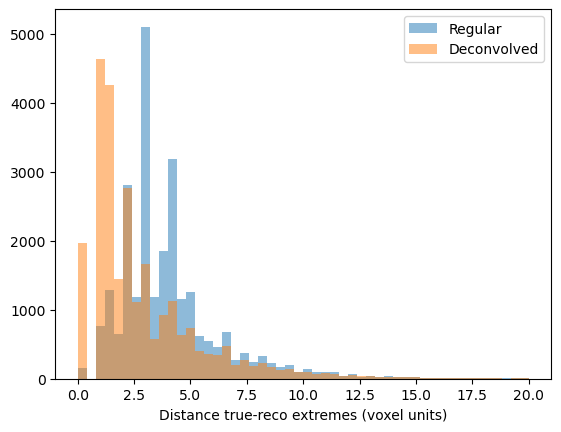

In [12]:
plt.hist(regular_vox_dist, 50, (0, 20), alpha = 0.5, label = 'Regular')
plt.hist(threshold_vox_dist, 50, (0, 20), alpha = 0.5, label = 'Deconvolved')
plt.xlabel('Distance true-reco extremes (voxel units)')
plt.legend()

In [16]:
np.mean(regular_vox_dist), np.mean(threshold_vox_dist)

(4.13722760030025, 3.086498885744283)

In [17]:
np.mean(regular_dist), np.mean(threshold_dist)

(59.025975247279064, 41.05519724422564)

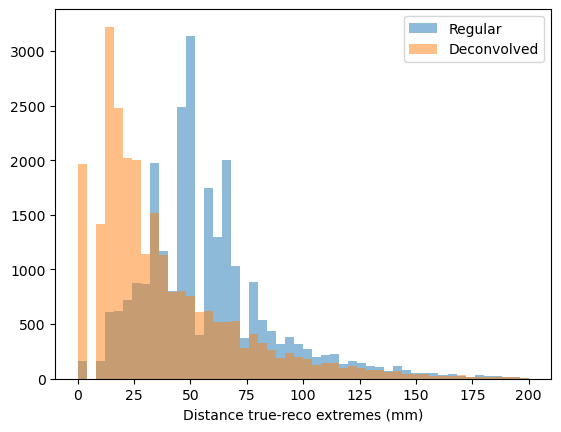

In [13]:
plt.hist(regular_dist, 50, (0, 200), alpha = 0.5, label = 'Regular')
plt.hist(threshold_dist, 50, (0, 200), alpha = 0.5, label = 'Deconvolved')
plt.xlabel('Distance true-reco extremes (mm)')
plt.legend()

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def get_discrete_classes(data_list, tol=1e-9):
    """Return sorted array of unique discrete distance values across all datasets."""
    all_vals = np.concatenate([np.asarray(d) for d in data_list])
    unique = np.unique(np.round(all_vals, 6))
    return unique


# ---------------------------------------------------------------------------
# 1. ECDF plot
# ---------------------------------------------------------------------------
def plot_ecdf(
    data_dict: dict,
    title: str = "ECDF of extreme-finding distances",
    xlabel: str = "Distance",
    units: str = "voxels",
    annotate_classes: bool = True,
    ax=None,
    figsize=(8, 5),
    xlim=None,
):
    """
    Plot the Empirical CDF for one or more distance arrays.

    Parameters
    ----------
    data_dict : dict  {label: array-like}
        Keys are algorithm names, values are 1-D arrays of distances.
    title : str
        Plot title.
    xlabel : str
        Label for the x-axis (excluding units).
    units : str
        Unit string appended to the x-axis label.
    annotate_classes : bool
        If True, draw vertical dashed lines at each discrete distance class.
    ax : matplotlib Axes or None
        Axes to draw on. If None, a new figure is created.
    figsize : tuple
        Figure size (only used when ax is None).

    Returns
    -------
    fig, ax
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure()

    classes = get_discrete_classes(list(data_dict.values()))

    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for (label, data), color in zip(data_dict.items(), colors):
        data = np.sort(np.asarray(data, dtype=float))
        n = len(data)
        # ECDF: y[i] = (i+1)/n  evaluated at data[i]
        y = np.arange(1, n + 1) / n
        # Draw as a step function; prepend a zero so the curve starts at 0
        x_step = np.concatenate([[data[0]], data])
        y_step = np.concatenate([[0.0], y])
        ax.step(x_step, y_step, where="post", label=f"{label}",
                color=color, linewidth=2)
        # Mark the jump positions
        ax.scatter(data, y, s=2, color=color, zorder=4, alpha=0.7)

    if annotate_classes:
        for c in classes:
            ax.axvline(c, color="grey", linewidth=0.6, linestyle="--", alpha=0.5)
        # Label a few key ones along the top
        ylim_top = 1.02
        for c in classes[:8]:   # avoid crowding
            ax.text(c, ylim_top, f"{c:.2f}", ha="center", va="bottom",
                    fontsize=6.5, color="grey", rotation=90)

    ax.set_xlabel(f"{xlabel} ({units})", fontsize=20)
    ax.set_ylabel("Cumulative fraction", fontsize=20)
    ax.set_ylim(-0.03, 1.10)
    ax.set_xlim(xlim)
    ax.tick_params(axis='both', labelsize=20)
    ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
    ax.legend(fontsize=20, loc = 'lower right')
    ax.grid(True, axis="y", linestyle=":", alpha=0.5)
    fig.tight_layout()
    return fig, ax




In [15]:
data_dist = {'Reconstructed':regular_dist, 'Deconvolved':threshold_dist}

(<Figure size 800x500 with 1 Axes>,
 <AxesSubplot:xlabel='Distance (mm)', ylabel='Cumulative fraction'>)

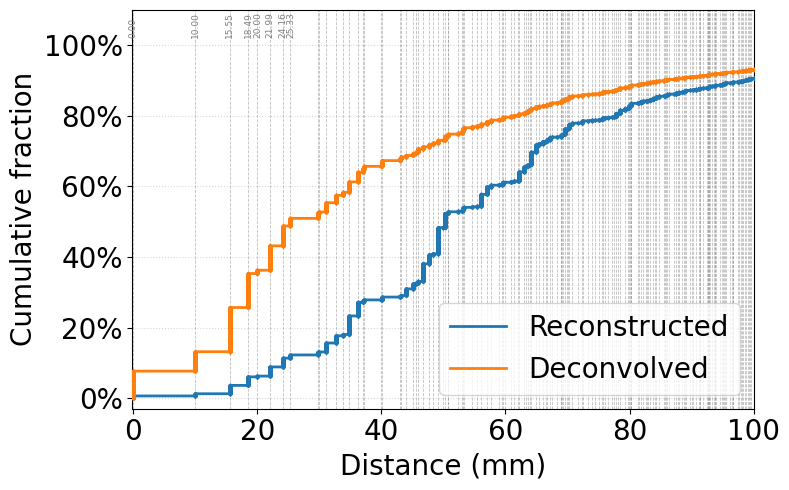

In [25]:
plot_ecdf(
    data_dist,
    title= "ECDF of extreme-finding distances",
    xlabel = "Distance",
    units = "mm",
    annotate_classes = True,
    ax=None,
    figsize=(8, 5),
    xlim=(-0.15, 100),
)

(<Figure size 800x500 with 1 Axes>,
 <AxesSubplot:xlabel='Distance ((voxel units))', ylabel='Cumulative fraction'>)

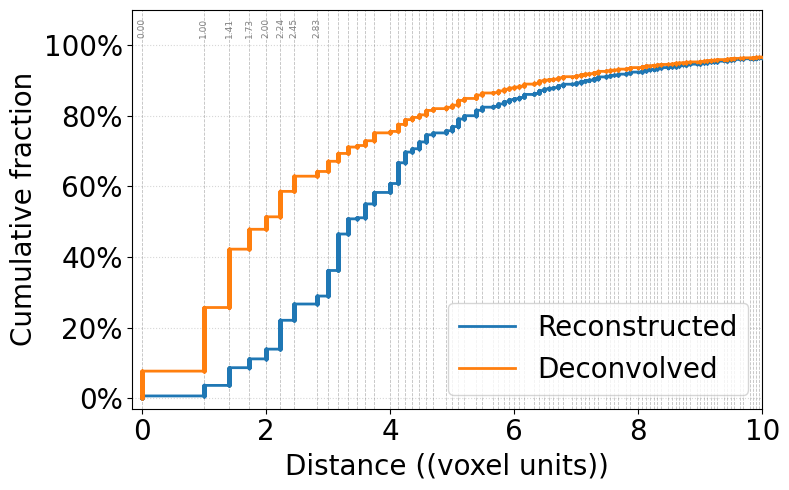

In [21]:
plot_ecdf(
    {'Reconstructed':regular_vox_dist, 'Deconvolved':threshold_vox_dist},
    xlabel = "Distance",
    units = "(voxel units)",
    annotate_classes = True,
    ax=None,
    figsize=(8, 5),
    xlim=(-0.15, 10),
)

In [ ]:
# ---------------------------------------------------------------------------
# 2. Dot / strip plot
# ---------------------------------------------------------------------------
def plot_strip(
    data_dict: dict,
    title: str = "Strip plot of extreme-finding distances",
    xlabel: str = "Distance",
    units: str = "voxels",
    jitter_seed: int = 42,
    annotate_classes: bool = True,
    ax=None,
    figsize=(9, 4),
    xlim = None,
):
    """
    Plot a vertical strip / dot plot for one or more distance arrays.
    Points are jittered vertically within each algorithm band.

    Parameters
    ----------
    data_dict : dict  {label: array-like}
        Keys are algorithm names, values are 1-D arrays of distances.
    title : str
        Plot title.
    xlabel : str
        Label for the x-axis (excluding units).
    units : str
        Unit string appended to the x-axis label.
    jitter_seed : int
        Random seed for reproducible jitter.
    annotate_classes : bool
        If True, draw vertical dashed lines at each discrete distance class.
    ax : matplotlib Axes or None
        Axes to draw on. If None, a new figure is created.
    figsize : tuple
        Figure size (only used when ax is None).

    Returns
    -------
    fig, ax
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure()

    rng = np.random.default_rng(jitter_seed)
    classes = get_discrete_classes(list(data_dict.values()))
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    n_algos = len(data_dict)
    band_height = 0.35          # half-height of the jitter band per algorithm
    spacing = 1.0               # vertical spacing between algorithm bands

    yticks, ylabels = [], []

    for i, ((label, data), color) in enumerate(zip(data_dict.items(), colors)):
        data = np.asarray(data, dtype=float)
        y_center = i * spacing
        jitter = rng.uniform(-band_height, band_height, size=len(data))

        ax.scatter(data, y_center + jitter,
                   s=18, color=color, alpha=0.55, linewidths=0,
                   label=label, zorder=3)

        # Overlay median and IQR as a summary marker
        median = np.median(data)
        q1, q3 = np.percentile(data, [25, 75])
        ax.plot([q1, q3], [y_center, y_center],
                color=color, linewidth=4, alpha=0.8, solid_capstyle="round", zorder=4)
        ax.scatter([median], [y_center],
                   s=80, color="white", edgecolors=color, linewidths=2,
                   zorder=5)

        yticks.append(y_center)
        ylabels.append(f"{label}\n(n={len(data)})")

    if annotate_classes:
        for c in classes:
            ax.axvline(c, color="grey", linewidth=0.6, linestyle="--", alpha=0.45)

    ax.set_yticks(yticks)
    ax.set_yticklabels(ylabels, fontsize=10)
    ax.set_xlabel(f"{xlabel} ({units})", fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.set_ylim(-spacing * 0.8, (n_algos - 1) * spacing + spacing * 0.8)
    ax.set_xlim(xlim)
    ax.grid(True, axis="x", linestyle=":", alpha=0.5)

    # Legend for the summary markers
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='grey',
               markeredgecolor='grey', markersize=7, label='Median'),
        Line2D([0], [0], color='grey', linewidth=4, alpha=0.8, label='IQR'),
    ]
    ax.legend(handles=legend_elements, fontsize=9, loc="upper right")

    fig.tight_layout()
    return fig, ax



In [19]:
# plot_strip(
#     data_dist,
#     title = "Strip plot of extreme-finding distances",
#     xlabel = "Distance",
#     units = "voxels",
#     jitter_seed = 42,
#     annotate_classes = True,
#     ax=None,
#     figsize=(9, 4),
#     xlim = (-0.1, 200),
# )

In [8]:
cosa = []
for dat_id in range(100):
    true_ext = events_voxel[(events_voxel.dataset_id == dat_id) & (events_voxel.extlabel != 0)]
    if len(true_ext) != 2:
        print(dat_id, events_voxel[(events_voxel.dataset_id == dat_id)].binclass.unique())
        cosa.append(dat_id)

1 [0]
6 [0]
9 [0]
12 [0]
16 [0]
27 [0]
38 [0]
40 [0]
50 [0]
55 [0]
66 [0]
69 [0]
73 [0]
75 [0]
77 [0]
78 [0]
84 [0]
86 [0]
87 [0]
88 [0]


In [9]:
evinf = events_info[events_info.dataset_id == cosa[2]]

In [10]:
dir = evinf.pathname.values[0] + '/' + evinf.basename.values[0]

In [11]:
labdir = evinf.label_pathname.values[0] + '/' + evinf.label_basename.values[0]

In [12]:
pd.read_hdf(labdir, 'DATASET/BinsInfo')

,min_x,total_x,size_x,max_x,nbins_x,min_y,total_y,size_y,max_y,nbins_y,...,total_z,size_z,max_z,nbins_z,detector_db,binning,Rmax,loss_th,ener_th,max_dis
0,-490.4,972.65,15.55,497.8,64,-487.7,972.65,15.55,500.5,64,...,1300,10,1300,130,next100,sipm,500,0.25,None,1.732051


In [13]:
from utils.bin_utils          import bins_creator_sipm, create_bins
from invisible_cities.database          import load_db as db


# Create bins
min_, max_, size_ = (-500, -500, 0), (500, 500, 1300), (10, 10, 10)

sipm_db = db.DataSiPM('next100', 0)
bin_info = bins_creator_sipm(sipm_db, min_[-1], max_[-1], size_[-1])
bins, bin_info = create_bins(bin_info)

In [22]:
from utils.labelling_utils import add_hits_labels_MC, voxel_labelling_MC, hit_data_cuts

from utils.add_extreme_utils import add_vox_ext_label


#Obtenemos la información de partíuclas y hits de un fichero en concreto
mcpart = pd.read_hdf(dir, 'MC/particles')
mchits = pd.read_hdf(dir, 'MC/hits')


#Seleccionamos los hits activos
mchits = mchits[mchits.label == 'ACTIVE']

#Etiquetamos los hits
labelled_hits = add_hits_labels_MC(mchits, mcpart, sig_creator = 'conv',
                                    blob_ener_loss_th = 0.25, blob_ener_th = None)

labelled_hits = hit_data_cuts(labelled_hits, bins, Rmax = 500)

# Vozelize with new function
voxelization_df = voxel_labelling_MC(labelled_hits, bins)

# Add extreme information to voxels using the hits
voxelization_df = add_vox_ext_label(labelled_hits, voxelization_df, bins)

# Make sure at least the extreme voxels have a blob label (this replaces the small blob mask for MC true hits)
# Adding 3 as the label for a voxel with both extremes
voxelization_df.loc[voxelization_df['extlabel'].isin([1, 3])    & (voxelization_df.binclass == 0), 'segclass'] = 3
voxelization_df.loc[voxelization_df['extlabel'].isin([1, 2, 3]) & (voxelization_df.binclass == 1), 'segclass'] = 3

# Reorder to match previous approach
voxelization_df['segclass'] = voxelization_df['segclass'].astype(int)

In [24]:
from utils.reco_labelling_utils import voxelize_reco, label_reco_event

column_names = ['event', 'X', 'Y', 'Z', 'Ec']
#reco hits voxelization
reco_voxels = voxelize_reco(dir, bins, labelled_vox = voxelization_df, interpol_params = dict(interpolate = False), group = 'RECO', table = 'Events', column_names = column_names, Rmax = 500)

# Define the 26 neighbor shifts
neighbor_shifts = [(dx, dy, dz) for dx in (-1, 0, 1) for dy in (-1, 0, 1) for dz in (-1, 0, 1) if (dx, dy, dz) != (0, 0, 0)]

# Label event by event
labelled_reco_voxels = pd.DataFrame()
for event_id, group in reco_voxels.groupby(column_names[0]):
    mc_ev   = voxelization_df[voxelization_df['event_id'] == event_id]
    reco_ev = group
    labeled_voxels_event = label_reco_event(mc_ev, reco_ev, neighbor_shifts, ghost_label=0)
    labelled_reco_voxels = pd.concat([labelled_reco_voxels, labeled_voxels_event], ignore_index=True)

#Turn into an integer
labelled_reco_voxels.segclass = pd.to_numeric(labelled_reco_voxels.segclass, downcast = 'integer')

# Add ext label to reco voxels
labelled_reco_voxels = labelled_reco_voxels.merge(voxelization_df[['x', 'y', 'z', 'extlabel', 'event_id']], on = ['x', 'y', 'z', 'event_id'], how='left')
labelled_reco_voxels['extlabel'] = labelled_reco_voxels['extlabel'].fillna(0).astype(int)

In [42]:
events_info[events_info.dataset_id == cosa[1]]

,event_id,binclass,dataset_id,pathname,basename,label_pathname,label_basename,total_energy,stridx,endidx
6,81000006,0,6,/mnt/lustre/scratch/nlsas/home/usc/ie/mpm/NEXT...,sophronia_1351_208Tl.h5,/mnt/lustre/scratch/nlsas/home/usc/ie/mpm/NEXT...,sophronia_label_1351_208Tl.h5,1.645709,2066,2427


In [43]:
voxelization_df[voxelization_df.event_id == 81000006].extlabel.unique()

array([0, 2, 1])

In [44]:
voxelization_df[(voxelization_df.event_id == 81000006) & (voxelization_df.extlabel == 2)]

,x,y,z,ener,ratio,segclass,nhits,binclass,event_id,extlabel
348,35,35,102,0.016445,0.709658,2,23,0,81000006,2


In [45]:
labelled_reco_voxels[labelled_reco_voxels.event_id == 81000006].extlabel.unique()

array([], dtype=int64)

In [41]:
labelled_reco_voxels[(labelled_reco_voxels.event_id == 81000001)].z.min()

101

In [40]:
labelled_reco_voxels[(labelled_reco_voxels.event_id == 81000001)]

,x,y,z,reco_ener,ratio,nhits,binclass,event_id,segclass,extlabel
383,37,48,110,0.001242,1.0,1,0,81000001,2,0
384,37,48,113,0.001929,1.0,1,0,81000001,2,0
385,37,48,114,0.001521,1.0,1,0,81000001,2,0
386,37,49,114,0.001507,1.0,1,0,81000001,2,0
387,37,50,113,0.002232,1.0,1,0,81000001,2,0
...,...,...,...,...,...,...,...,...,...,...
756,52,52,104,0.001138,1.0,1,0,81000001,3,0
757,52,52,105,0.001887,1.0,2,0,81000001,3,0
758,52,53,105,0.001073,1.0,1,0,81000001,3,0
759,52,53,106,0.001787,1.0,1,0,81000001,3,0


In [31]:
voxelization_df

,x,y,z,ener,ratio,segclass,nhits,binclass,event_id,extlabel
0,39,48,52,0.021720,1.000000,2,13,0,81000000,0
1,39,49,52,0.006480,1.000000,2,2,0,81000000,0
2,39,49,53,0.019875,1.000000,2,15,0,81000000,0
3,39,50,52,0.016998,1.000000,2,9,0,81000000,0
4,39,50,53,0.011057,1.000000,2,7,0,81000000,0
...,...,...,...,...,...,...,...,...,...,...
5303,50,43,43,0.044749,0.999978,2,23,1,81000104,0
5304,50,43,48,0.016439,1.000000,2,8,1,81000104,0
5305,50,43,49,0.017700,1.000000,2,11,1,81000104,0
5306,50,44,48,0.062285,0.775997,2,31,1,81000104,0


In [25]:
for did in cosa:
    a = events_info[events_info.dataset_id == did]
    c = labelled_hits[labelled_hits.event_id == a.event_id.values[0]].extlabel.unique()
    d = voxelization_df[voxelization_df.event_id == a.event_id.values[0]].extlabel.unique()
    e = labelled_reco_voxels[labelled_reco_voxels.event_id == a.event_id.values[0]].extlabel.unique()
    print(did, c, d, e)

1 [0. 2. 1.] [0 2 1] [0 1]
6 [0. 2. 1.] [0 2 1] []
9 [0. 2. 1.] [0 2 1] []
12 [0. 2. 1.] [1 0 2] []
16 [2. 0. 1.] [0 1 2] [0 1]
27 [0. 2. 1.] [0 2 1] [0 1]
38 [0. 2. 1.] [1 0 2] []
40 [0. 2. 1.] [0 2 1] [0 1]
50 [0. 2. 1.] [0 3] []
55 [0. 2. 1.] [0 1 2] []
66 [2. 0. 1.] [0 1 2] []
69 [0. 2. 1.] [0 2 1] [0 1]
73 [0. 2. 1.] [0 1 2] [0 1]
75 [0. 2. 1.] [0 1 2] [0 1]
77 [0. 2. 1.] [0 2 1] [0 1]
78 [0. 2. 1.] [0 1 2] [0 1]
84 [0. 2. 1.] [0 2 1] [0 1]
86 [0. 2. 1.] [0 3] [0 3]
87 [0. 2. 1.] [0 2 1] [0 1]
88 [0. 2. 1.] [0 2 1] [0 1]


In [ ]:

    # Vozelize with new function
    voxelization_df = voxel_labelling_MC(labelled_hits, bins)

    # Add extreme information to voxels using the hits
    voxelization_df = add_vox_ext_label(labelled_hits, voxelization_df, bins)

In [209]:
evinf

,event_id,binclass,dataset_id,pathname,basename,label_pathname,label_basename,total_energy,stridx,endidx
9,81000009,0,9,/mnt/lustre/scratch/nlsas/home/usc/ie/mpm/NEXT...,sophronia_1351_208Tl.h5,/mnt/lustre/scratch/nlsas/home/usc/ie/mpm/NEXT...,sophronia_label_1351_208Tl.h5,1.529458,3214,3523


In [210]:
labelled_hits[labelled_hits.event_id == evinf.event_id.values[0]].extlabel.unique()

array([0., 2., 1.])

In [178]:
mcpart

,event_id,particle_id,particle_name,primary,mother_id,initial_x,initial_y,initial_z,initial_t,final_x,...,initial_momentum_x,initial_momentum_y,initial_momentum_z,final_momentum_x,final_momentum_y,final_momentum_z,kin_energy,length,creator_proc,final_proc
0,81060000,1,Tl208,True,0,398.265594,400.965576,563.969971,0.000000,398.265594,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,none,RadioactiveDecay
1,81060000,4,e-,False,1,398.265594,400.965576,563.969971,0.000351,398.243103,...,-0.044128,-0.443871,-0.016678,-0.000000,0.000000,-0.000000,0.167504,0.068909,RadioactiveDecay,eIoni
2,81060000,3,anti_nu_e,False,1,398.265594,400.965576,563.969971,0.000351,-3869.718506,...,-0.396719,1.018267,-1.214327,-0.396719,1.018267,-1.214327,1.633660,17575.236328,RadioactiveDecay,Transportation
3,81060000,2,Pb208[3197.711],False,1,398.265594,400.965576,563.969971,0.000351,398.265594,...,0.440846,-0.574395,1.231003,0.000000,-0.000000,0.000000,0.000005,0.000000,RadioactiveDecay,RadioactiveDecay
4,81060000,6,gamma,False,2,398.265594,400.965576,563.969971,0.000351,367.911469,...,-0.147746,0.471693,0.309492,-0.000000,-0.000000,0.000000,0.583188,90.659943,RadioactiveDecay,phot
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8963,81060099,84,e-,False,33,153.051575,303.948608,501.986359,2.427671,153.145889,...,-0.099256,0.118247,-0.080551,-0.000000,0.000000,-0.000000,0.028855,1.306814,eIoni,eIoni
8964,81060099,83,e-,False,33,155.164734,302.159637,501.166595,2.412679,155.071320,...,-0.046209,-0.036955,0.106162,-0.000000,-0.000000,0.000000,0.014254,0.388382,eIoni,eIoni
8965,81060099,82,e-,False,33,175.565567,273.798737,509.484650,1.938408,175.410233,...,-0.084076,-0.021591,0.080172,0.000000,-0.000000,0.000000,0.013484,0.611475,eIoni,eIoni
8966,81060099,81,e-,False,33,280.079132,204.786362,412.673370,0.964863,280.058655,...,-0.033836,0.065087,-0.081693,0.000000,-0.000000,0.000000,0.011662,0.220981,eIoni,eIoni
